# Prediction Workflow

This notebook implements the end-to-end disease risk prediction pipeline.
It takes raw patient data as input, applies all preprocessing steps in the correct order, generates a risk prediction using the optimized threshold of
0.45, and provides a SHAP-based explanation of the prediction. This workflow represents the core deliverable of the Disease Risk Prediction System.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

file_path = r"C:\Courses\DAMG6105\Project - Disease Prediction System"

# Load trained model
with open(f'{file_path}/outputs/models/logistic_regression.pkl', 'rb') as f:
    lr_model = pickle.load(f)

# Load saved preprocessing objects
with open(f'{file_path}/outputs/models/knn_imputer.pkl', 'rb') as f:
    imputer = pickle.load(f)

with open(f'{file_path}/outputs/models/standard_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open(f'{file_path}/outputs/models/chol_bounds.pkl', 'rb') as f:
    chol_bounds = pickle.load(f)

# Load training data for SHAP explainer
X_train = pd.read_csv(f'{file_path}/data/processed/X_train.csv')

# Extract bounds
chol_lower = chol_bounds['lower']
chol_upper = chol_bounds['upper']
cols_to_scale = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

print("All components loaded successfully.")
print(f"Model: {type(lr_model).__name__}")
print(f"Cholesterol bounds: [{chol_lower:.1f}, {chol_upper:.1f}]")
print(f"Scaler means: {dict(zip(cols_to_scale, scaler.mean_.round(2)))}")

All components loaded successfully.
Model: LogisticRegression
Cholesterol bounds: [30.9, 407.1]
Scaler means: {'age': np.float64(53.21), 'trestbps': np.float64(131.49), 'chol': np.float64(198.39), 'thalch': np.float64(137.33), 'oldpeak': np.float64(0.88)}


In [7]:
def preprocess_patient(patient_data):
    """
    Preprocesses raw patient data through the complete pipeline.
    
    Parameters:
    patient_data (dict): Raw patient features
    
    Returns:
    pd.DataFrame: Preprocessed patient data ready for prediction
    """
    
    # Step 1 - Convert input to DataFrame
    df = pd.DataFrame([patient_data])
    
    # Step 2 - Drop non-clinical columns if present
    df = df.drop(columns=['id', 'dataset'], errors='ignore')
    
    # Step 3 - Encode binary columns
    df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
    df['fbs'] = df['fbs'].map({True: 1, False: 0, 
                                'True': 1, 'False': 0})
    df['exang'] = df['exang'].map({True: 1, False: 0,
                                    'True': 1, 'False': 0})
    
    # Step 4 - Encode multi-category columns
    df['cp'] = df['cp'].map({
        'typical angina': 0,
        'atypical angina': 1,
        'non-anginal': 2,
        'asymptomatic': 3
    })
    df['restecg'] = df['restecg'].map({
        'normal': 0,
        'st-t abnormality': 1,
        'lv hypertrophy': 2
    })
    df['slope'] = df['slope'].map({
        'upsloping': 0,
        'flat': 1,
        'downsloping': 2
    })
    
    # Step 5 - Encode thal
    df['thal'] = df['thal'].map({
        'normal': 0,
        'fixed defect': 1,
        'reversable defect': 2
    })
    
    # Step 6 - Add missing indicators
    df['ca_missing'] = df['ca'].isnull().astype(int)
    df['thal_missing'] = df['thal'].isnull().astype(int)
    
    # Step 7 - Ensure correct column order matching training data
    df = df.reindex(columns=X_train.columns, fill_value=np.nan)
    
    # Step 8 - Apply KNN Imputation
    df_imputed = pd.DataFrame(
        imputer.transform(df),
        columns=df.columns
    )
    
    # Step 9 - Apply Winsorization before scaling 
    df_imputed['chol'] = df_imputed['chol'].clip(
        chol_lower, chol_upper
    )

    
    # Step 10 - Apply StandardScaler
    df_imputed[cols_to_scale] = scaler.transform(
        df_imputed[cols_to_scale]
    )
    
    
    return df_imputed

print("Preprocessing function defined successfully.")

Preprocessing function defined successfully.


In [8]:
def predict_disease_risk(patient_data):
    """
    Predicts disease risk for a new patient.
    
    Parameters:
    patient_data (dict): Raw patient features
    
    Returns:
    dict: Prediction results including risk level, probability and SHAP explanation
    """
    
    # Step 1 - Preprocess patient data
    processed = preprocess_patient(patient_data)
    
    # Step 2 - Get disease probability
    probability = lr_model.predict_proba(processed)[0][1]
    
    # Step 3 - Apply optimized threshold
    prediction = 1 if probability >= 0.45 else 0
    risk_label = "HIGH RISK" if prediction == 1 else "LOW RISK"
    
    # Step 4 - Calculate SHAP values
    explainer = shap.LinearExplainer(lr_model, X_train)
    shap_values = explainer.shap_values(processed)
    
    # Step 5 - Build SHAP explanation dataframe
    shap_df = pd.DataFrame({
        'Feature': processed.columns,
        'Value': processed.iloc[0].values,
        'SHAP Value': shap_values[0]
    }).sort_values('SHAP Value', key=abs, ascending=False)
    
    # Step 6 - Print results
    print("=" * 50)
    print("DISEASE RISK PREDICTION RESULTS")
    print("=" * 50)
    print(f"Risk Level:        {risk_label}")
    print(f"Disease Probability: {probability:.1%}")
    print(f"Decision Threshold:  0.45")
    print("\nTop 5 Contributing Factors:")
    print("-" * 50)
    for _, row in shap_df.head(5).iterrows():
        direction = "↑ Risk" if row['SHAP Value'] > 0 else "↓ Risk"
        print(f"  {row['Feature']:<15} {direction}  "
              f"(impact: {row['SHAP Value']:+.3f})")
    print("=" * 50)
    
    # Step 7 - Generate waterfall plot
    plt.figure()
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value,
            data=processed.iloc[0],
            feature_names=processed.columns.tolist()
        ),
        show=False
    )
    plt.title(f'SHAP Explanation — {risk_label} '
              f'({probability:.1%} probability)')
    plt.tight_layout()
    plt.savefig(f'{file_path}/outputs/figures/prediction_explanation.png',
                bbox_inches='tight')
    plt.show()
    
    return {
        'risk_label': risk_label,
        'probability': probability,
        'prediction': prediction,
        'shap_values': shap_df
    }

print("Prediction function defined successfully.")

Prediction function defined successfully.


Testing with high risk patient profile:
--------------------------------------------------
  age: 58
  sex: Male
  cp: asymptomatic
  trestbps: 140
  chol: 270
  fbs: False
  restecg: lv hypertrophy
  thalch: 120
  exang: True
  oldpeak: 2.5
  slope: flat
  ca: 1.0
  thal: reversable defect
--------------------------------------------------
DISEASE RISK PREDICTION RESULTS
Risk Level:        HIGH RISK
Disease Probability: 95.8%
Decision Threshold:  0.45

Top 5 Contributing Factors:
--------------------------------------------------
  oldpeak         ↑ Risk  (impact: +0.886)
  exang           ↑ Risk  (impact: +0.531)
  thal_missing    ↑ Risk  (impact: +0.403)
  ca_missing      ↓ Risk  (impact: -0.402)
  cp              ↑ Risk  (impact: +0.396)


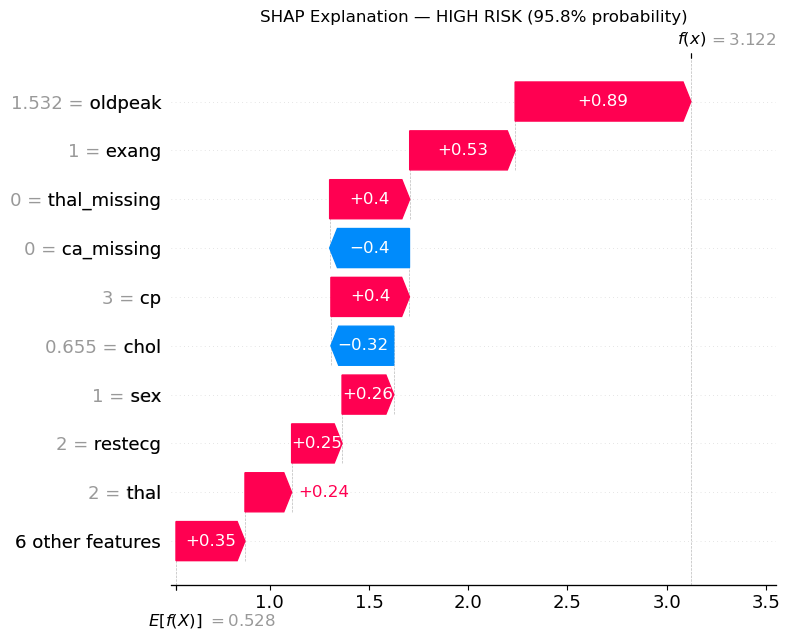

In [13]:
# Test patient - High risk profile
high_risk_patient = {
    'age': 58,
    'sex': 'Male',
    'cp': 'asymptomatic',
    'trestbps': 140,
    'chol': 270,
    'fbs': False,
    'restecg': 'lv hypertrophy',
    'thalch': 120,
    'exang': True,
    'oldpeak': 2.5,
    'slope': 'flat',
    'ca': 1.0,
    'thal': 'reversable defect'
}

print("Testing with high risk patient profile:")
print("-" * 50)
for key, value in high_risk_patient.items():
    print(f"  {key}: {value}")
print("-" * 50)

result = predict_disease_risk(high_risk_patient)

Testing with low risk patient profile:
--------------------------------------------------
  age: 35
  sex: Female
  cp: typical angina
  trestbps: 118
  chol: 195
  fbs: False
  restecg: normal
  thalch: 170
  exang: False
  oldpeak: 0.0
  slope: upsloping
  ca: 0.0
  thal: normal
--------------------------------------------------
DISEASE RISK PREDICTION RESULTS
Risk Level:        LOW RISK
Disease Probability: 1.6%
Decision Threshold:  0.45

Top 5 Contributing Factors:
--------------------------------------------------
  cp              ↓ Risk  (impact: -1.432)
  sex             ↓ Risk  (impact: -0.704)
  ca              ↓ Risk  (impact: -0.510)
  oldpeak         ↓ Risk  (impact: -0.481)
  thal_missing    ↑ Risk  (impact: +0.403)


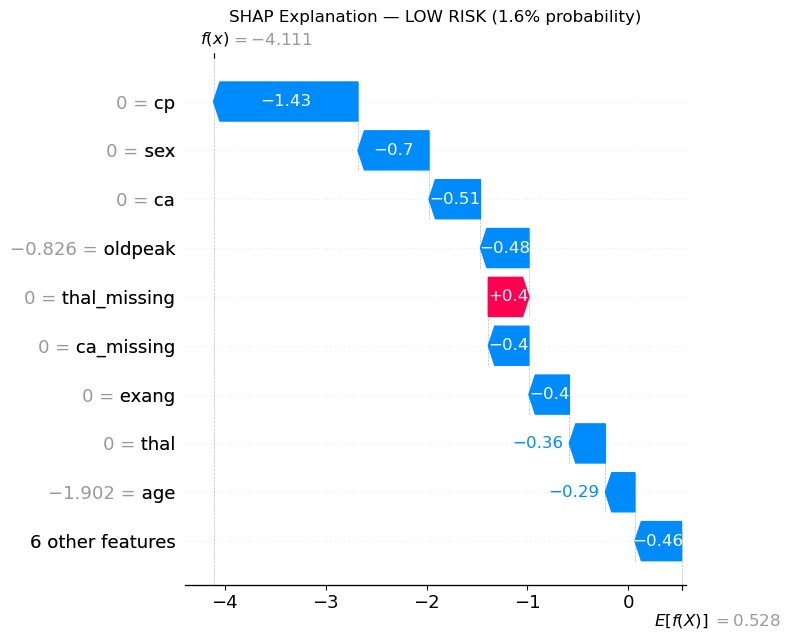

In [14]:
# Test patient - Low risk profile
low_risk_patient = {
    'age': 35,
    'sex': 'Female',
    'cp': 'typical angina',
    'trestbps': 118,
    'chol': 195,
    'fbs': False,
    'restecg': 'normal',
    'thalch': 170,
    'exang': False,
    'oldpeak': 0.0,
    'slope': 'upsloping',
    'ca': 0.0,
    'thal': 'normal'
}

print("Testing with low risk patient profile:")
print("-" * 50)
for key, value in low_risk_patient.items():
    print(f"  {key}: {value}")
print("-" * 50)

result = predict_disease_risk(low_risk_patient)

## Prediction Workflow Testing

### High Risk Patient Test
- Male, 58 years, asymptomatic chest pain, exercise induced angina, oldpeak=2.5, reversable defect thal
- Result: HIGH RISK - 95.8% disease probability
- Top contributors: oldpeak (+0.886), exang (+0.531), cp (+0.396)
- Prediction is clinically consistent - patient presents with multiple strong disease indicators simultaneously

### Low Risk Patient Test
- Female, 35 years, typical angina, no exercise angina, thalch=170, normal thal, oldpeak=0.0
- Result: LOW RISK - 1.6% disease probability
- Top contributors: cp (-1.432), sex (-0.704), ca (-0.510)
- Clinically consistent - young female with no significant disease indicators

### Pipeline Validation
- Both predictions are clinically sensible and consistent with patterns identified throughout EDA, modeling, and SHAP analysis
- Preprocessing pipeline correctly handles raw input data including encoding, imputation, scaling, and Winsorization in the correct order
- SHAP explanations provide transparent, feature level reasoning for every prediction

# Notebook 08 Summary - Prediction Workflow

## Overview
This notebook implements the complete end-to-end disease risk prediction pipeline, representing the core deliverable of the Disease Risk Prediction
System. The workflow takes raw patient data as input and produces an interpretable risk prediction with feature-level explanations.

## Pipeline Architecture

Raw Patient Data (dictionary input)
        ↓
Categorical Encoding (same mappings as training)
        ↓
Missing Indicator Addition (ca_missing, thal_missing)
        ↓
Column Alignment (reindex to match training feature order)
        ↓
KNN Imputation (loaded from saved imputer)
        ↓
Winsorization (cholesterol bounds from training data)
        ↓
StandardScaler (loaded from saved scaler)
        ↓
Logistic Regression Prediction (threshold 0.45)
        ↓
SHAP Explanation (waterfall plot + top contributors)
        ↓
Risk Label + Probability + Feature Contributions

## Key Implementation Decisions

### Saved Preprocessing Objects
- KNN Imputer, StandardScaler, and cholesterol bounds were saved in notebook 02 and loaded here - ensuring identical preprocessing
  to training without requiring X_train to be present
- This is the correct production approach - preprocessing parameters are fixed at training time and never recalculated on new data

### Optimized Threshold
- Decision threshold of 0.45 applied consistently - same as notebook 06
- Ensures equitable performance across male and female patients

### Preprocessing Order
- Winsorization applied before scaling - bounds are in unscaled units
- Imputation applied before scaling - KNN operates on original feature scale for meaningful distance calculations

## Test Results

| Patient Profile | Risk Level | Probability |
|---|---|---|
| Male, 58, asymptomatic, exang=True, oldpeak=2.5 | HIGH RISK | 95.8% |
| Female, 35, typical angina, exang=False, oldpeak=0.0 | LOW RISK | 1.6% |

## Limitations & Future Improvements
- Preprocessing objects should be versioned alongside the model to ensure consistency in production deployment
- The current workflow accepts dictionary input - a future improvement would add a user interface (web form or API) for clinical use
- Model should be periodically retrained as new patient data becomes available to maintain performance over time

## Project Deliverables Complete
- Generalized disease risk prediction framework
- Reproducible preprocessing and modeling pipeline
- Interpretable predictions with SHAP explanations
- Optimized threshold addressing demographic bias
- Validated on held-out test set (ROC-AUC 0.9204)
- Documented limitations and ethical considerations